In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from utils import logger
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

os.chdir(config.paths.roots.project)

torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam0 : 579
INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam1 : 579
INFO     | setup | Train Dataset       : 1158 samples
INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam0 : 579
INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam1 : 579
INFO     | setup | Validation Dataset  : 1158 samples


In [4]:
dl = dm.train_dataloader()

In [5]:
batch = next(iter(dl))

In [6]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

rotations = batch.rotations
print(rotations.shape)

torch.Size([238, 3, 32, 32]) torch.Size([238, 3, 32, 32])
torch.Size([238, 2]) torch.Size([238, 2])
torch.Size([238])


In [7]:
euclidean_distance = torch.norm(patch_level_reference_coords - patch_level_target_coords, p=2, dim=1)
euclidean_distance.shape

torch.Size([238])

tensor([ -0.5014,  -0.5014, 168.9694,  -2.5070,   4.5125,   2.5070,  -3.5097,
         -1.5042,   4.5125,  -3.5097,  -1.5042,  -0.5014, -10.5292,   0.5014,
          0.5014,   1.5042,  -1.5042,  -0.5014,   2.5070,  -5.5153,  -0.5014,
         -2.5070,   1.5042,   4.5125,  -1.5042,   0.5014,   7.5209,   3.5097,
          4.5125,  -3.5097,   0.5014,   2.5070,  -3.5097,   2.5070,   0.5014,
         49.6379,  -1.5042, -15.5432,  -3.5097,  -1.5042,   0.5014,  -5.5153,
          0.5014,  -0.5014,  -2.5070,  -3.5097,  -0.5014,  -0.5014])


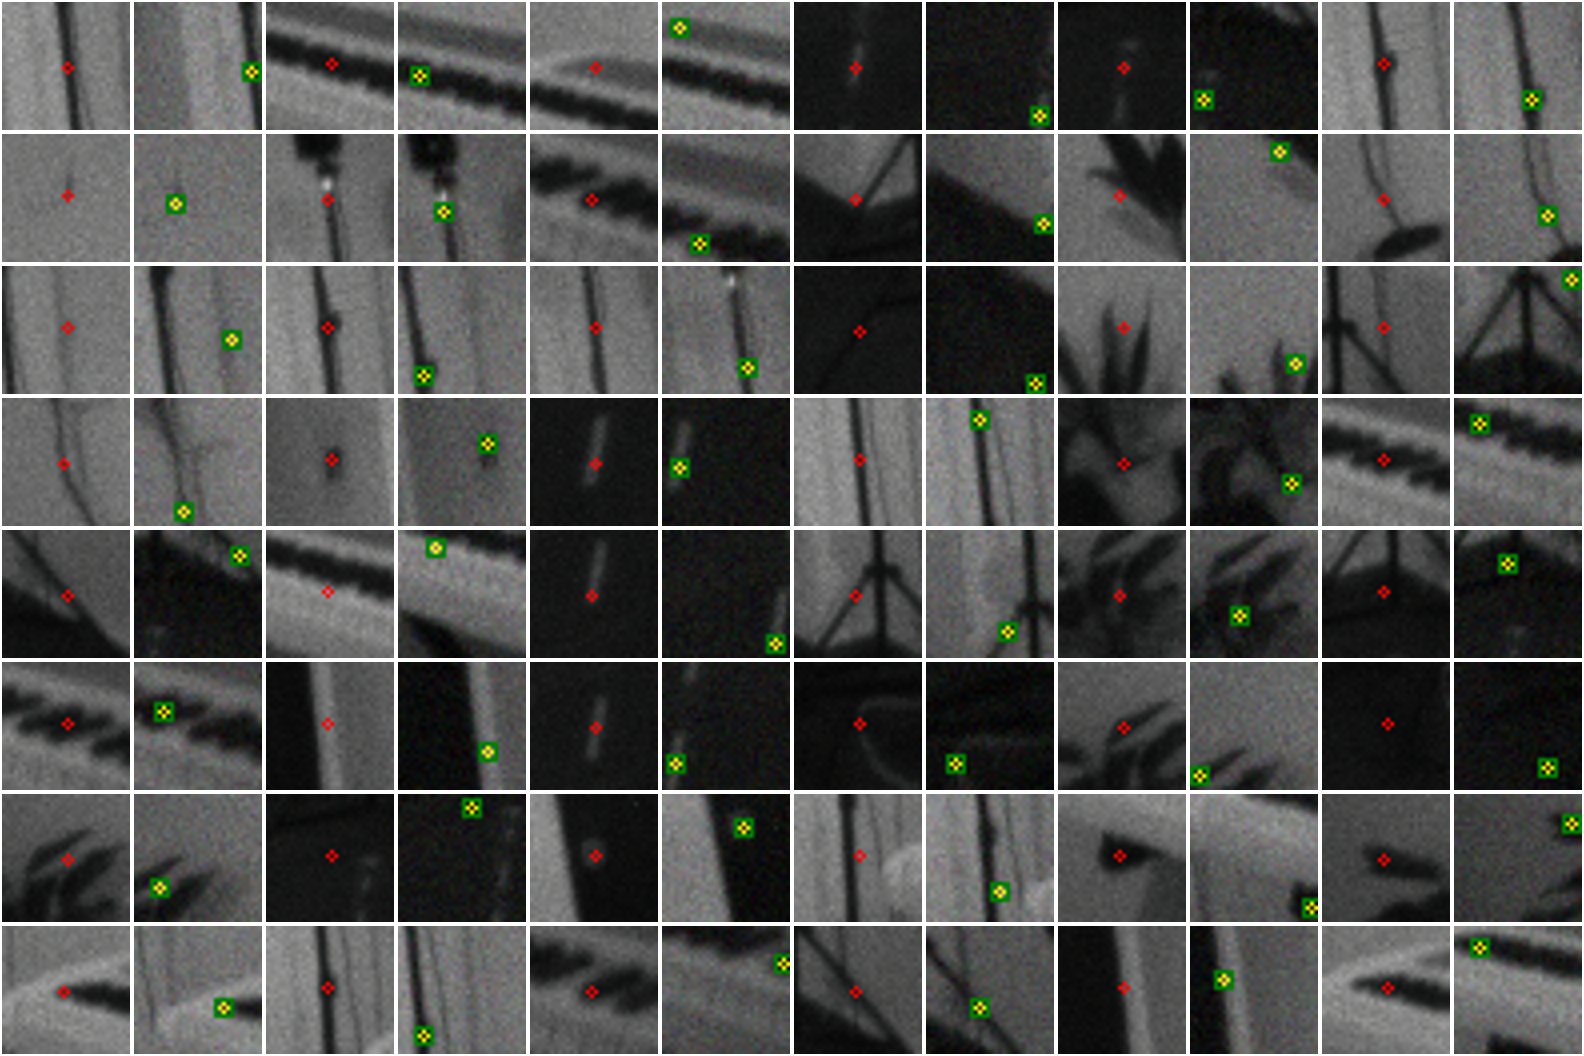

In [8]:
from utils import show_batch

count = 24 * 2

print(batch.rotations[:count] * (180 / np.pi))

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    limit_count=count, 
    n_columns=6,
)

In [9]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)


In [10]:
dm.teardown()

# Check Model

In [14]:
from src import Light
light = Light()

In [12]:
from utils import count_params
count_params(light.model)

416388

In [15]:
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

# reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

target_coords, target_rotation, target_confidence = light(reference_patches, target_patches, patch_level_reference_coords)

print(f'target_coords shape : {target_coords.shape}')
print(f'target_rotation shape : {target_rotation.shape}')
print(f'target_confidence shape : {target_confidence.shape}')

reference_patches shape : torch.Size([238, 3, 32, 32])
target_patches shape : torch.Size([238, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([238, 2])


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!